In [ ]:
qimport pandas as pd

df = pd.DataFrame({
    "Order_ID": [101,102,103,104,105,106,107,108],
    "Product": ["Laptop","Mobile","Tablet","Headphones","Smartwatch","Laptop","Mobile","Tablet"],
    "Category": ["Electronics","Electronics","Electronics","Accessories","Accessories","Electronics","Electronics","Electronics"],
    "Quantity": [2,5,3,8,4,1,6,2],
    "Revenue": [100000,75000,45000,16000,20000,50000,90000,30000],
    "Profit": [20000,15000,9000,4000,5000,10000,18000,6000],
    "Customer_City": ["Hyderabad","Vijayawada","Hyderabad","Vizag","Guntur","Vizag","Hyderabad","Vijayawada"]
})

print(df)

   Order_ID     Product     Category  Quantity  Revenue  Profit Customer_City
0       101      Laptop  Electronics         2   100000   20000     Hyderabad
1       102      Mobile  Electronics         5    75000   15000    Vijayawada
2       103      Tablet  Electronics         3    45000    9000     Hyderabad
3       104  Headphones  Accessories         8    16000    4000         Vizag
4       105  Smartwatch  Accessories         4    20000    5000        Guntur
5       106      Laptop  Electronics         1    50000   10000         Vizag
6       107      Mobile  Electronics         6    90000   18000     Hyderabad
7       108      Tablet  Electronics         2    30000    6000    Vijayawada


In [ ]:
print("Total Revenue =", df["Revenue"].sum())

print("Total Profit =", df["Profit"].sum())

print("Highest Revenue Product =")
print(df.loc[df["Revenue"].idxmax(), "Product"])

print("Highest Profit Product =")
print(df.loc[df["Profit"].idxmax(), "Product"])

Total Revenue = 426000
Total Profit = 87000
Highest Revenue Product =
Laptop
Highest Profit Product =
Laptop


In [ ]:
print(df.groupby("Category")["Revenue"].sum())

print(df.groupby("Category")["Profit"].sum())

Category
Accessories     36000
Electronics    390000
Name: Revenue, dtype: int64
Category
Accessories     9000
Electronics    78000
Name: Profit, dtype: int64


In [ ]:
print(df.groupby("Customer_City")["Revenue"].sum())

print(df.groupby("Customer_City")["Profit"].sum())

Customer_City
Guntur         20000
Hyderabad     235000
Vijayawada    105000
Vizag          66000
Name: Revenue, dtype: int64
Customer_City
Guntur         5000
Hyderabad     47000
Vijayawada    21000
Vizag         14000
Name: Profit, dtype: int64


In [ ]:
print(df.groupby("Product")["Quantity"].sum())

print("Top Selling Product:")
print(df.groupby("Product")["Quantity"].sum().idxmax())

Product
Headphones     8
Laptop         3
Mobile        11
Smartwatch     4
Tablet         5
Name: Quantity, dtype: int64
Top Selling Product:
Mobile


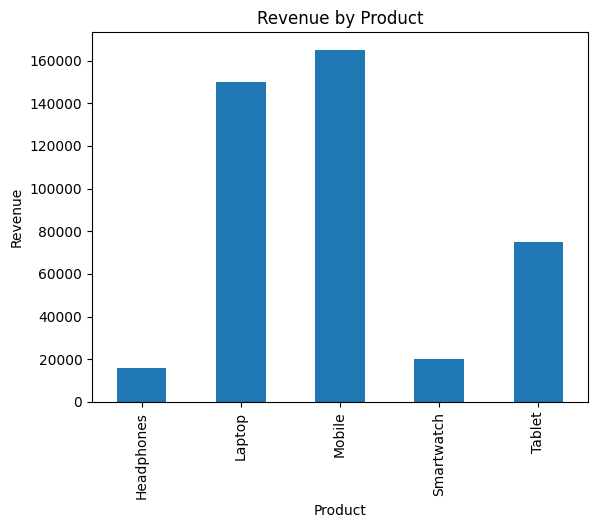

In [ ]:
import matplotlib.pyplot as plt

sales = df.groupby("Product")["Revenue"].sum()

sales.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

In [ ]:
profit = df.groupby("Product")["Profit"].sum()

print(profit)

print("Highest Profit Product:")
print(profit.idxmax())

print("Lowest Profit Product:")
print(profit.idxmin())

Product
Headphones     4000
Laptop        30000
Mobile        33000
Smartwatch     5000
Tablet        15000
Name: Profit, dtype: int64
Highest Profit Product:
Mobile
Lowest Profit Product:
Headphones


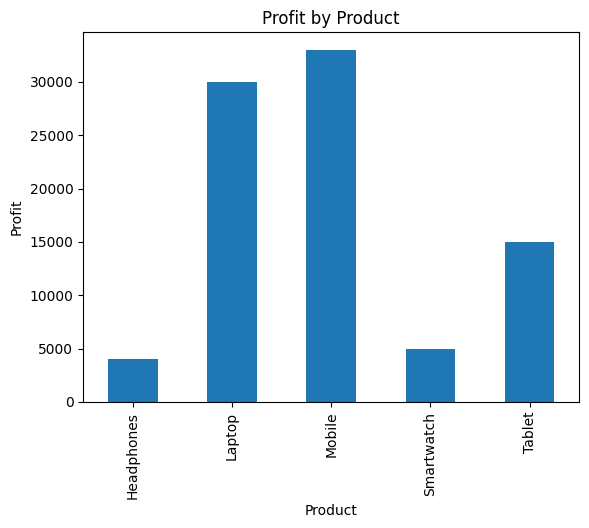

In [ ]:
import matplotlib.pyplot as plt

profit = df.groupby("Product")["Profit"].sum()

profit.plot(kind="bar")

plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")

plt.show()

In [ ]:
df.to_csv("sales_data.csv", index=False)

print("CSV File Created Successfully!")

CSV File Created Successfully!


In [11]:
new_df = pd.read_csv("sales_data.csv")

print(new_df.head())

   Order_ID     Product     Category  Quantity  Revenue  Profit Customer_City
0       101      Laptop  Electronics         2   100000   20000     Hyderabad
1       102      Mobile  Electronics         5    75000   15000    Vijayawada
2       103      Tablet  Electronics         3    45000    9000     Hyderabad
3       104  Headphones  Accessories         8    16000    4000         Vizag
4       105  Smartwatch  Accessories         4    20000    5000        Guntur


In [12]:
print(new_df.shape)

print(new_df.columns)

(8, 7)
Index(['Order_ID', 'Product', 'Category', 'Quantity', 'Revenue', 'Profit',
       'Customer_City'],
      dtype='object')


In [13]:
print(new_df.describe())

        Order_ID  Quantity        Revenue        Profit
count    8.00000  8.000000       8.000000      8.000000
mean   104.50000  3.875000   53250.000000  10875.000000
std      2.44949  2.356602   31896.036476   6104.740547
min    101.00000  1.000000   16000.000000   4000.000000
25%    102.75000  2.000000   27500.000000   5750.000000
50%    104.50000  3.500000   47500.000000   9500.000000
75%    106.25000  5.250000   78750.000000  15750.000000
max    108.00000  8.000000  100000.000000  20000.000000


In [14]:
print(new_df.isnull().sum())


Order_ID         0
Product          0
Category         0
Quantity         0
Revenue          0
Profit           0
Customer_City    0
dtype: int64


In [15]:
new_df["Revenue"].fillna(new_df["Revenue"].mean(), inplace=True)

print("Missing values handled")

Missing values handled


/tmp/ipykernel_3042/4127919643.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df["Revenue"].fillna(new_df["Revenue"].mean(), inplace=True)


In [16]:
X = new_df[["Quantity"]]

y = new_df["Revenue"]

print(X.head())

print(y.head())

   Quantity
0         2
1         5
2         3
3         8
4         4
0    100000
1     75000
2     45000
3     16000
4     20000
Name: Revenue, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6, 1)
(2, 1)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [20]:
prediction = model.predict([[4]])

print("Predicted Revenue =", prediction[0])

Predicted Revenue = 50809.2485549133


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

score = r2_score(y_test, y_pred)

print("R2 Score =", score)

R2 Score = -2.007200775167898


In [24]:
from google.colab import files
files.download('sales_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>